## Exploratory Data Analysis ##

In [172]:
%pip install --upgrade pandas
%pip install pathlib
%pip install pyarrow

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [173]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
import pyarrow as pa

In [174]:
#Setting the path
data_path = Path('/Users/Priyanka/Documents/Internship-Internmo/Zomato_BI_Project/data/cleaned')

In [175]:
#loading the cleaned datasets
cities = pd.read_parquet(data_path / 'cities_cleaned.parquet')
customer_feedback = pd.read_parquet(data_path / 'customer_feedback_cleaned.parquet')
customers = pd.read_parquet(data_path / 'customers_cleaned.parquet')
delivery_partners = pd.read_parquet(data_path / 'delivery_partners_cleaned.parquet')
menu = pd.read_parquet(data_path / 'menu_cleaned.parquet')
order_items = pd.read_parquet(data_path / 'order_items_cleaned.parquet')
orders = pd.read_parquet(data_path / 'orders_cleaned.parquet')
payments = pd.read_parquet(data_path / 'payments_cleaned.parquet')
promotions = pd.read_parquet(data_path / 'promotions_cleaned.parquet')
restaurants = pd.read_parquet(data_path / 'restaurants_cleaned.parquet')
traffic = pd.read_parquet(data_path / 'traffic_cleaned.parquet')
weather = pd.read_parquet(data_path / 'weather_cleaned.parquet')



In [176]:
print(cities.columns.tolist())

['CityID', 'City', 'Population', 'Region', 'AverageIncome']


In [177]:
orders.head()

,OrderID,CustomerID,RestaurantID,DeliveryPartnerID,OrderDate,OrderTime,DeliveryTimeMinutes,FoodCost,DeliveryFee,Discount,CouponCode,GST,FinalAmount,OrderStatus,PaymentMethod
0,100001,7095,474,121,2023-06-17,11:51:00,43,206.0,40.0,103.0,Zomkxzzw,10.30,153.30,Delivered,Cash On Delivery
1,100002,9498,828,1776,2023-07-01,10:18:00,18,425.0,20.0,127.5,Zom72K4N,21.25,338.75,Food Not Delivered,Debit Card
2,100003,11040,105,27,2023-05-09,19:34:00,50,287.0,30.0,28.7,Zomqjt3W,14.35,302.65,Cancelled,Net Banking
3,100004,2553,923,361,2024-06-22,00:26:00,29,60.0,25.0,0.0,NaN,3.00,88.00,Delivered,Credit Card
4,100005,8294,940,160,2024-03-17,12:27:00,25,582.0,49.0,145.5,Zomcfy14,29.10,514.60,Delivered,Upi


In [178]:
restaurants.head()

,RestaurantID,RestaurantName,Cuisine,City,Area,OpeningTime,ClosingTime,Rating,AverageCost,OwnerName,RestaurantType,Latitude,Longitude
0,1,Curry Cafe,Healthy Food,Vadodara,Civil Lines,09:00:00,23:00:00,3.4,328.0,Qarin Ray,Delivery Only,15.884170,88.525722
1,2,Curry Treats,Burgers,Surat,Market Area,07:00:00,00:00:00,NaN,525.0,Manan Bala,Delivery Only,13.581113,87.706587
2,3,Blue Kitchen,Healthy Food,Nashik,Mg Road,07:00:00,01:00:00,4.3,171.0,Nicholas Manne,Cloud Kitchen,22.629797,75.921274
3,4,The Grill,Biryani,Nashik,Station Road,08:00:00,00:00:00,3.3,258.0,Harsh Bhargava,Dine-In & Delivery,16.648774,79.743892
4,5,Golden Diner,Chinese,Pune,Ring Road,11:00:00,22:00:00,3.3,529.0,Daksha Narayanan,Dine-In,30.278253,77.396672


In [179]:
# Palette Definition
ZOMATO_RED = "#E23744"
ZOMATO_DARK_RED = "#CB202D"
CHARCOAL = "#2D2D2D"
NEUTRAL_BOX = "#F4F4F2"
NEUTRAL_GREY = "#E0E0E0"

#Setting the style for seaborn plots
sns.set_theme(style="darkgrid", palette="pastel")

# Global Matplotlib Configurations
plt.rcParams.update(
    {
        # --- Fonts ---
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial"],
        # --- Titles & Subtitles ---
        "figure.titlesize": 16,  # Main Title
        "figure.titleweight": "bold",
        "axes.titlesize": 14,  # Subplot Title / Subtitle
        "axes.titleweight": "semibold",
        "axes.titlepad": 12,
        "axes.titlecolor": CHARCOAL,
        # --- Labels & Ticks ---
        "axes.labelsize": 11,
        "axes.labelweight": "medium",
        "axes.labelcolor": CHARCOAL,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "xtick.color": CHARCOAL,
        "ytick.color": CHARCOAL,
        # --- Figure & Layout ---
        "figure.figsize": (10, 5),
        "figure.dpi": 150,
        "figure.autolayout": True,
        "figure.facecolor": "white",
        # --- Axes & Spines ---
        "axes.edgecolor": NEUTRAL_GREY,
        "axes.linewidth": 0.8,
        "axes.facecolor": "#F8F9FA",
        "axes.spines.top": False,
        "axes.spines.right": False,
        # --- Gridlines ---
        "axes.grid": True,
        "grid.color": NEUTRAL_GREY,
        "grid.linestyle": "--",
        "grid.linewidth": 0.6,
        "grid.alpha": 0.7,
        # --- Legend ---
        "legend.fontsize": 10,
        "legend.frameon": True,
        "legend.framealpha": 0.9,
        "legend.edgecolor": NEUTRAL_GREY,
        "legend.facecolor": "white",
    }
)

# Apply Palette Globally to Seaborn
zomato_palette = [
    ZOMATO_RED,
    ZOMATO_DARK_RED,
    CHARCOAL,
    NEUTRAL_GREY,
    NEUTRAL_BOX,
]
sns.set_palette(sns.color_palette(zomato_palette))

In [180]:
# Standardize Datetime Types
orders["OrderDate"] = pd.to_datetime(orders["OrderDate"], errors="coerce")
orders["OrderTime"] = pd.to_datetime(
    orders["OrderTime"], format="%H:%M:%S", errors="coerce"
)

In [181]:
#Extracting time & date features from the 'order_time' and 'order_date' column in the orders dataset
orders['Hour'] = orders['OrderTime'].dt.hour
orders['DayOfWeek'] = orders['OrderDate'].dt.day_name()
orders['IsWeekend'] = orders['DayOfWeek'].isin(['Saturday', 'Sunday'])
orders['DayType'] = np.where(orders['IsWeekend'], 'Weekend', 'Weekday')
orders['Month'] = orders['OrderDate'].dt.month

In [182]:
print("Hour:")
print(orders['Hour'].head())
print("Day of Week:")
print(orders['DayOfWeek'].head())
print("Is Weekend:")
print(orders['IsWeekend'].head())
print("Day Type:")
print(orders['DayType'].head())

Hour:
0    11
1    10
2    19
3     0
4    12
Name: Hour, dtype: int32
Day of Week:
0    Saturday
1    Saturday
2     Tuesday
3    Saturday
4      Sunday
Name: DayOfWeek, dtype: str
Is Weekend:
0     True
1     True
2    False
3     True
4     True
Name: IsWeekend, dtype: bool
Day Type:
0    Weekend
1    Weekend
2    Weekday
3    Weekend
4    Weekend
Name: DayType, dtype: str


In [183]:
#Peak ordering hours analysis
hourly_summary = (
orders.groupby('Hour')['OrderID']
    .count()
    .reset_index(name = 'TotalOrders')
    .sort_values(by='TotalOrders', ascending=False)
)

In [184]:
print('Top 5 Peak Ordering Hours:')
print(hourly_summary.head(5).to_string(index=False))

Top 5 Peak Ordering Hours:
 Hour  TotalOrders
   19         1797
   12         1749
   13         1663
   20         1632
   18         1474


In [185]:
# Merging the orders and restaurants datasets for further analysis
df_ord_rest = orders.merge(restaurants[['RestaurantID','RestaurantName','Cuisine']],
                        on='RestaurantID', how='inner')

In [186]:
# 1. Top restaurants by revenue
top_restaurants = (
    df_ord_rest.groupby('RestaurantName')['FinalAmount']
    .sum()
    .reset_index(name='TotalRevenue')
    .sort_values(by='TotalRevenue', ascending=False)
    .head(10)
)
print("Top 10 Restaurants by Revenue:")
print(top_restaurants.to_string(index=False))

Top 10 Restaurants by Revenue:
RestaurantName  TotalRevenue
     The House     149972.25
 Grand Kitchen     127016.25
    Curry Cafe     126997.15
  Green Corner     126284.95
   Urban House     123242.45
   Urban Point     121843.90
 Curry Kitchen     119570.35
     The Point     118205.30
   Blue Treats     116701.45
   Urban Diner     114509.50


Output: The House, Grand Kitchen and Curry Cafe are generating the highest revenue of 1,49,972 rupees, 1,27,016 rupees and 1,26,997 rupees respectively.

In [187]:
# 2. Top cuisines by revenue
top_cuisines = (
    df_ord_rest.groupby('Cuisine')['FinalAmount']
    .sum()
    .reset_index(name='TotalRevenue')
    .sort_values(by='TotalRevenue', ascending=False)
    .head(10)
)
print("Top 10 Cuisines by Revenue:")
print(top_cuisines.to_string(index=False))

Top 10 Cuisines by Revenue:
     Cuisine  TotalRevenue
South Indian     551636.75
   Fast Food     511595.15
Healthy Food     488655.85
 Street Food     459435.90
    Desserts     448641.30
       Sushi     429632.30
 Continental     427730.70
       Pizza     427416.70
     Seafood     414767.75
     Mexican     405212.40


Output: South Indian, Fast food and Healthy food seem to be generating the most revenue with 5,51,636 rupees, 5,11,595 rupees and 4,88,655 rupees respectively.

In [188]:
# 3. Monthly revenue trend by cuisine over Time
df_ord_rest['YearMonth'] = df_ord_rest['OrderDate'].dt.to_period('M')
cuisine_monthly = (
    df_ord_rest.groupby(['YearMonth', 'Cuisine'])['FinalAmount']
    .sum()
    .unstack(fill_value=0)
)
print("Monthly Revenue Trend by Cuisine (Year-Month):")
print(cuisine_monthly)

Monthly Revenue Trend by Cuisine (Year-Month):
Cuisine      Bakery       Bbq   Biryani   Burgers   Chinese  Continental  \
YearMonth                                                                  
2023-01    17381.70  16768.55  21892.25  15553.25  14982.10     17118.10   
2023-02    17011.20  18121.65  23604.50  11462.20  13337.95     18284.65   
2023-03    13634.95  18664.00  20781.85  18313.65  15711.85     14807.60   
2023-04    16534.10  17277.60  14938.25  17839.60  12919.90     17052.55   
2023-05     8494.85  18629.00  12503.35  20616.90  12883.45     22567.20   
2023-06     7879.80  17352.05  13247.05  21670.50  17018.00     16545.20   
2023-07    13414.30  17135.25  11565.50  13546.70  14891.80     22116.85   
2023-08    20908.70  21180.55  15818.80  18681.55  16317.45     14817.30   
2023-09    17813.95  18591.75  14842.05  15609.60  15188.35     16988.65   
2023-10    13460.85  15144.20  16108.45  14231.05  14602.60     15706.55   
2023-11    14409.65  17594.65  16661.90  

In [189]:
# 4. Quarterly revenue trend by cuisine over Time
df_ord_rest['YearQuarter'] = df_ord_rest['OrderDate'].dt.to_period('Q')
cuisine_quarterly = (
    df_ord_rest.groupby(['YearQuarter', 'Cuisine'])['FinalAmount']
    .sum()
    .unstack(fill_value=0)
)
top_5_cuisines = (
    df_ord_rest.groupby('Cuisine')['FinalAmount']
    .sum()
    .nlargest(5)
    .index.tolist()
)
print("Quarterly Revenue Matrix (Top 5 cuisines:)")
print(cuisine_quarterly[top_5_cuisines])

Quarterly Revenue Matrix (Top 5 cuisines:)
Cuisine      South Indian  Fast Food  Healthy Food  Street Food  Desserts
YearQuarter                                                              
2023Q1           64327.75   65252.20      59292.05     52389.55  50177.85
2023Q2           72245.40   61507.05      58018.00     56269.55  59080.20
2023Q3           78822.35   63633.10      76524.00     63887.55  57732.10
2023Q4           70491.65   69371.45      57985.60     60476.65  64017.35
2024Q1           67247.55   54794.75      62534.75     62724.50  60605.50
2024Q2           65340.35   74453.35      57074.00     40746.80  51762.90
2024Q3           72177.85   60126.55      53326.15     54167.95  55206.30
2024Q4           60983.85   62456.70      63901.30     68773.35  50059.10


Output: 
- It is observed that in Quarter 1 of 2023 south indian and fast food generated similar highest revenues and Q2 & Q3 of 2023, South indian cuisine supplied with most revenue, followed with Q4 South indian and fast food were similar.
- In Q1 & Q3 of 2024, South Indian food was more profitable for the company, in Q2 Fast food was highest revenue generating but interestingly, in Q4 Street food surpassed but the in demand cuisines and generated the highest revenue. 

### Top Revenue Trend for Restaurants & Cuisines ###

/var/folders/14/vwm12jsj6k54dqpcrph9h29w0000gp/T/ipykernel_37856/4124443180.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


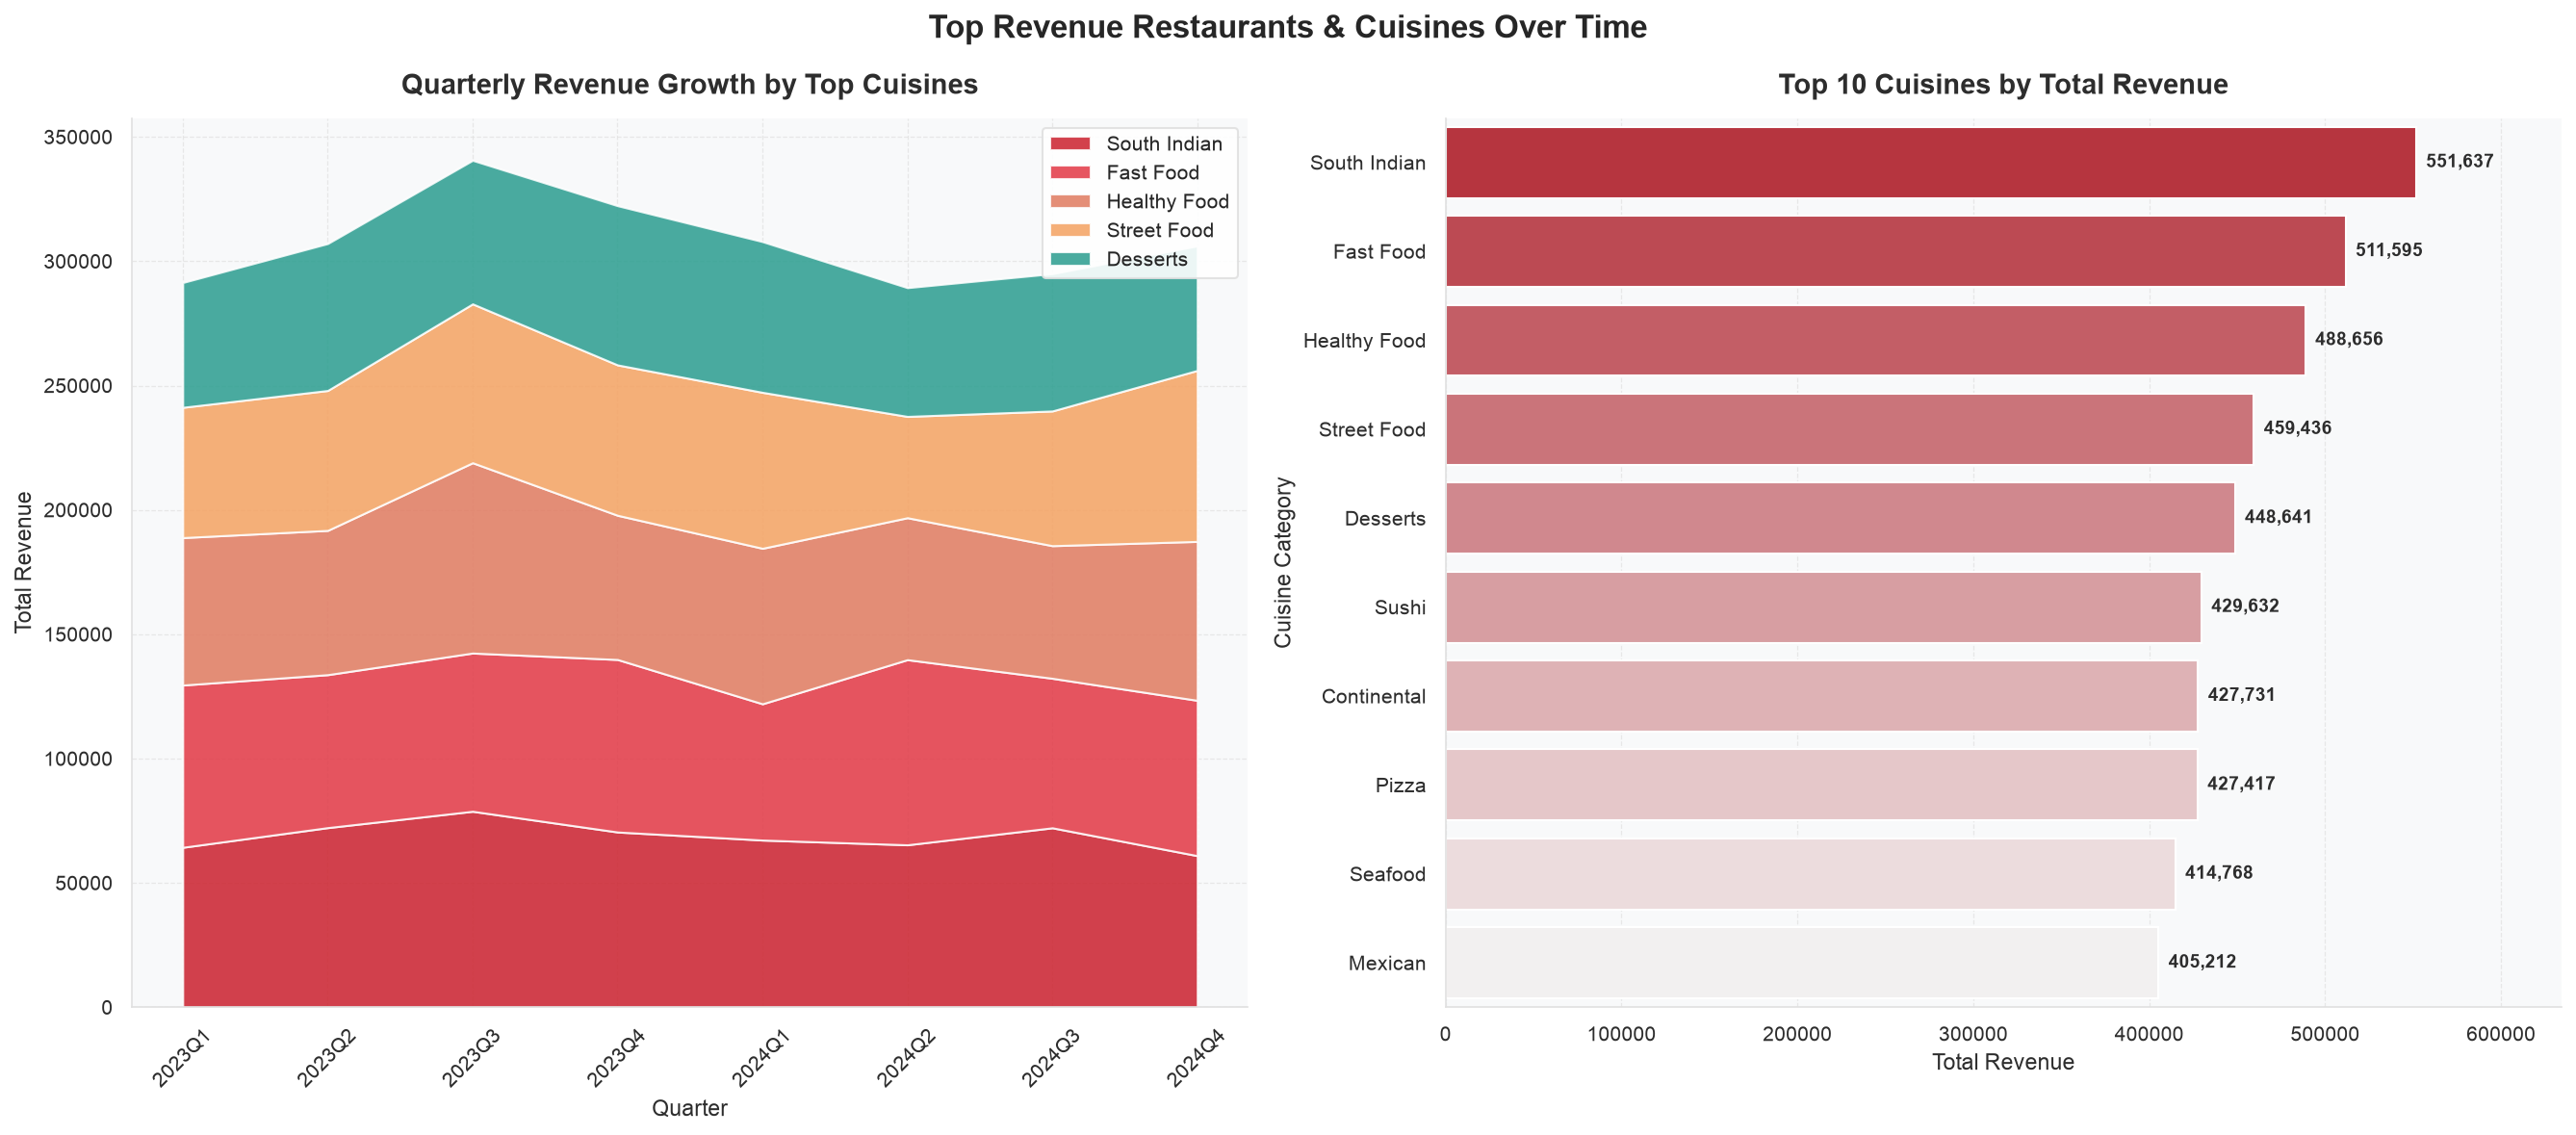

In [190]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle(
    'Top Revenue Restaurants & Cuisines Over Time',
)

# Chart 1 (Matplotlib): Quarterly Stacked Area Chart for Top 5 Cuisines
quarterly_top5 = cuisine_quarterly[top_5_cuisines]
quarterly_top5.index = quarterly_top5.index.astype(str)

axes[0].stackplot(
    quarterly_top5.index,
    quarterly_top5.values.T,
    labels=top_5_cuisines,
    colors=[
        ZOMATO_DARK_RED,
        ZOMATO_RED,
        '#E07A5F',
        '#F4A261',
        '#2A9D8F',
    ],
    alpha=0.85,
)
axes[0].set_title(
    'Quarterly Revenue Growth by Top Cuisines',
    fontweight='bold',
    fontsize=14,
    fontname='Arial',
    color=CHARCOAL,
)
axes[0].set_xlabel('Quarter')
axes[0].set_ylabel('Total Revenue')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(loc='upper right', frameon=True)

rank_palette = sns.light_palette(ZOMATO_DARK_RED, n_colors=10, reverse=True)

sns.barplot(
    data=top_cuisines,
    x='TotalRevenue',
    y='Cuisine',
    palette=rank_palette,
    ax=axes[1],
)
# Add value labels at the end of each bar
for container in axes[1].containers:
  axes[1].bar_label(
      container,
      fmt='{:,.0f}',
      padding=5,
      color=CHARCOAL,
      fontsize=9,
      fontweight='bold',
  )
# Extend x-axis limit slightly so labels don't get cut off at the edge
axes[1].set_xlim(0, top_cuisines['TotalRevenue'].max() * 1.15)
axes[1].set_title(
    'Top 10 Cuisines by Total Revenue',
    fontweight='bold',
    fontname='Arial',
    fontsize=14,
    color=CHARCOAL,
)
axes[1].set_xlabel('Total Revenue')
axes[1].set_ylabel('Cuisine Category')

plt.tight_layout()
plt.show()

Output: 
- It is observed that overall cumulative revenue across these top cuisines peaked in 2023Q3 at approximately 340,000.
- Total revenue experienced a slight contraction through 2023Q4 and 2024Q2 (dipping to around 2,88,000) before showing modest recovery in 2024Q4 (reaching back above 3,00,000).

### Peak Ordering Hours & Weekday vs. Weekend Demand Patterns ###

In [191]:
# Hourly volume matrix (Hour x DayType)
hourly_pivot = (
    orders.groupby(['Hour', 'DayType']).size().unstack(fill_value=0)
)

# Daily Order Volume by Day of Week
days_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday',
]
daily_volume = (
    orders.groupby('DayOfWeek').size().reindex(days_order).reset_index(name='OrderCount')
)
print("Hourly Order Volume Matrix (Weekday vs Weekend)")
print(hourly_pivot.tail(12))

print("\nDaily Order Volume Summary")
print(daily_volume.to_string(index=False))

peak_weekday_hour = hourly_pivot['Weekday'].idxmax()
peak_weekend_hour = hourly_pivot['Weekend'].idxmax()
print(f'\n✓ Weekday Peak Hour: {peak_weekday_hour}:00')
print(f'✓ Weekend Peak Hour: {peak_weekend_hour}:00')

Hourly Order Volume Matrix (Weekday vs Weekend)
DayType  Weekday  Weekend
Hour                     
12          1232      517
13          1198      465
14           809      287
15           662      260
16           644      256
17           760      300
18          1057      417
19          1269      528
20          1151      481
21           808      305
22           393      157
23           267      101

Daily Order Volume Summary
DayOfWeek  OrderCount
   Monday        2872
  Tuesday        2868
Wednesday        2991
 Thursday        2975
   Friday        2976
 Saturday        2904
   Sunday        2889

✓ Weekday Peak Hour: 19:00
✓ Weekend Peak Hour: 19:00


Output:
- Both weekdays and weekends the peak hours remain 7pm followed closely by 12pm as second most peak hour.

### Peak Ordering Hours Visualization ###

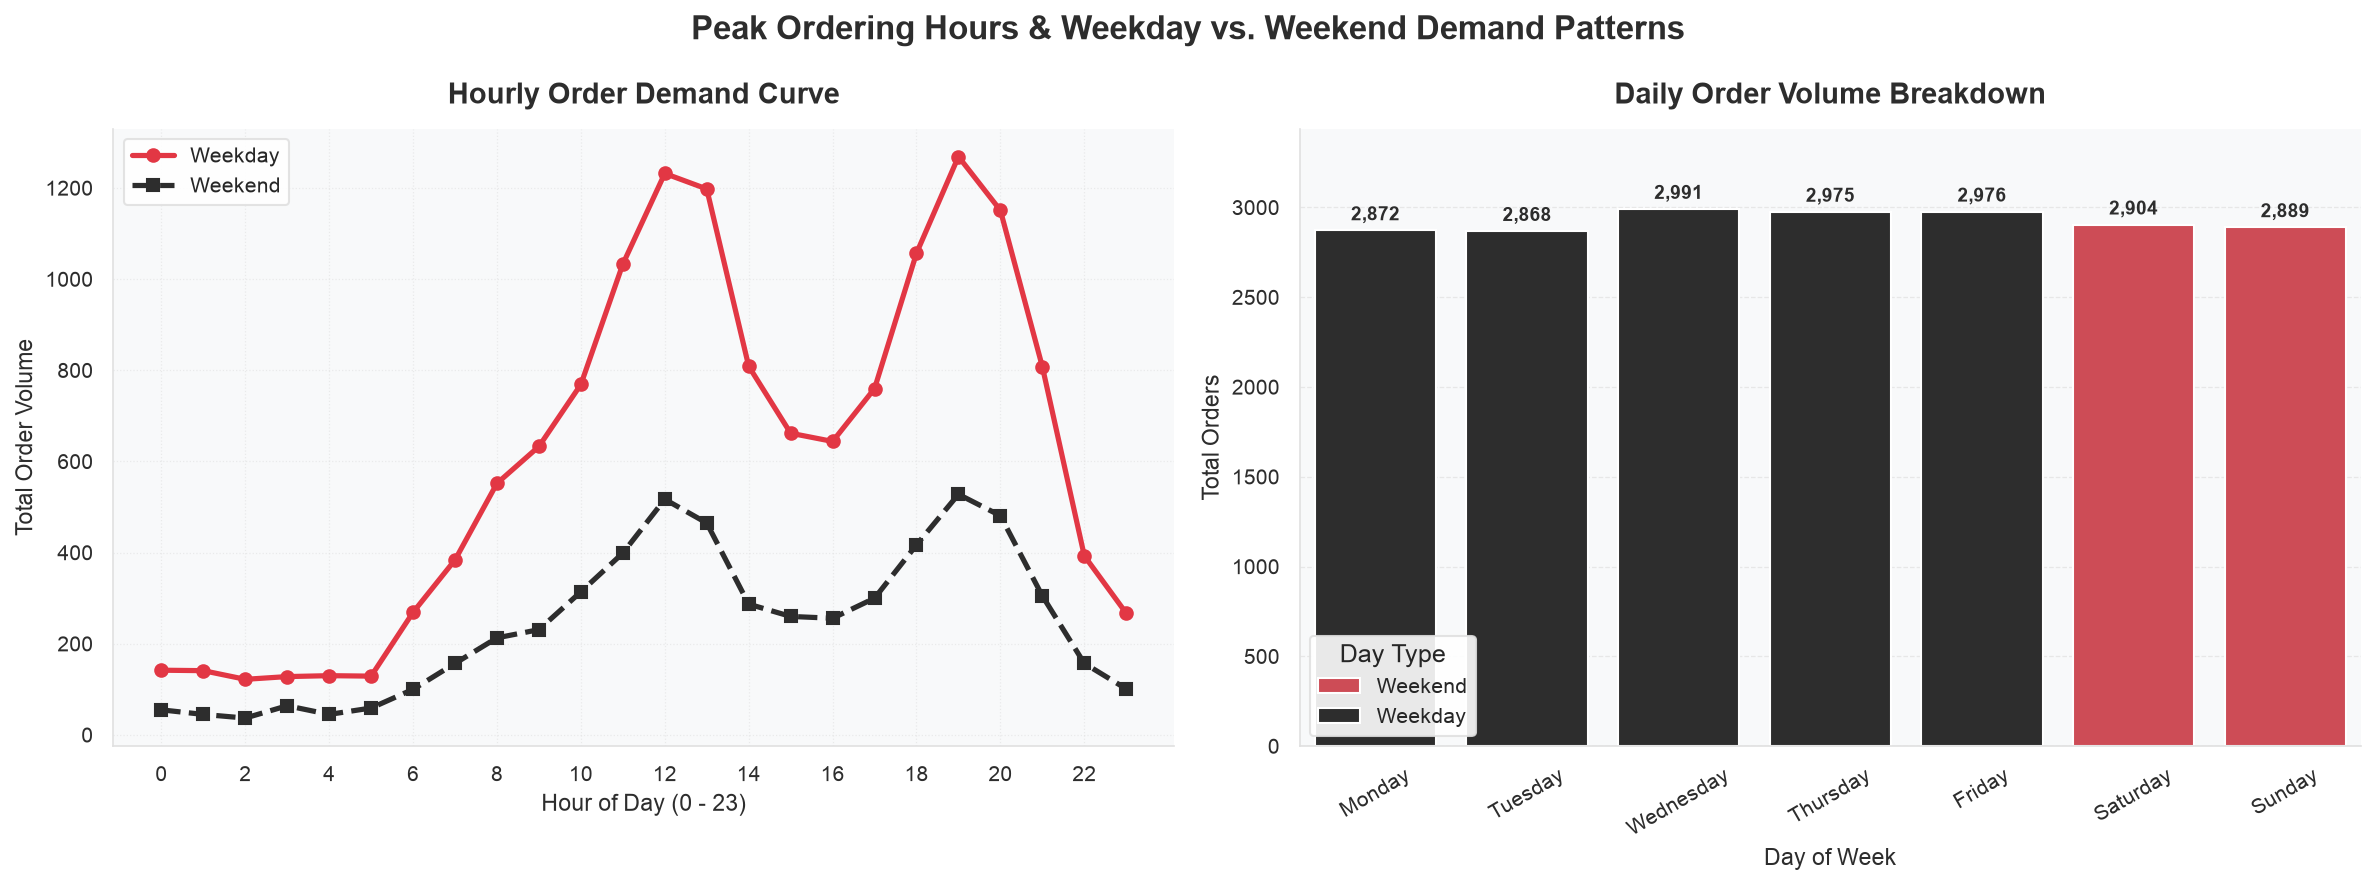

In [192]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'Peak Ordering Hours & Weekday vs. Weekend Demand Patterns',
    fontsize=16,
    fontname='Arial',
    fontweight='bold',
    color=CHARCOAL,
)
axes[0].plot(
    hourly_pivot.index,
    hourly_pivot['Weekday'],
    marker='o',
    color=ZOMATO_RED,
    linewidth=2.5,
    label='Weekday',
)
axes[0].plot(
    hourly_pivot.index,
    hourly_pivot['Weekend'],
    marker='s',
    color=CHARCOAL,
    linewidth=2.5,
    linestyle='--',
    label='Weekend',
)

axes[0].set_title(
    'Hourly Order Demand Curve',
    fontname='Arial',
    fontsize=14,
    fontweight='bold',
    color=CHARCOAL,
)
axes[0].set_xlabel('Hour of Day (0 - 23)')
axes[0].set_ylabel('Total Order Volume')
axes[0].set_xticks(range(0, 24, 2))
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend(loc='upper left', frameon=True)

sns.countplot(
    data=orders,
    x='DayOfWeek',
    order=days_order,
    hue='DayType',
    palette=[ZOMATO_RED, CHARCOAL],
    ax=axes[1],
)

# Add value labels on top of every bar
for container in axes[1].containers:
  axes[1].bar_label(
      container,
      fmt='{:,.0f}',
      padding=3,
      color=CHARCOAL,
      fontsize=9,
      fontweight='bold',
  )

# Extend y-axis limit so top labels don't get cut off
max_count = orders['DayOfWeek'].value_counts().max()
axes[1].set_ylim(0, max_count * 1.15)

axes[1].set_title(
    'Daily Order Volume Breakdown',
    fontweight='bold',
    fontsize=14,
    fontname='Arial',
    color=CHARCOAL,
)
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Total Orders')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Day Type', loc='lower left')

plt.tight_layout()
plt.show()

### Delivery Time Distribution & City Variance ###

In [193]:
# Merge orders with traffic and weather 
orders_tw = orders.copy()
q1_val = orders_tw['DeliveryTimeMinutes'].quantile(0.25)
q3_val = orders_tw['DeliveryTimeMinutes'].quantile(0.75)
iqr = q3_val - q1_val
cap_99 = orders_tw['DeliveryTimeMinutes'].quantile(0.99)

# Cap extreme delivery times at 99th percentile (preserving record count)
orders_tw['DeliveryTimeCapped'] = orders_tw['DeliveryTimeMinutes'].clip(
    upper=cap_99
)
print("Delivery Outlier Summary:")
print(
    f'Q1: {q1_val:.1f} mins | Q3: {q3_val:.1f} mins | IQR: {iqr:.1f} mins'
)
print(f'99th Percentile Cap Value: {cap_99:.1f} mins')
print(
    f'Max Raw Delivery Time: {orders_tw["DeliveryTimeMinutes"].max():.1f} mins'
)
print(
    f'Max Capped Delivery Time: {orders_tw["DeliveryTimeCapped"].max():.1f} mins'
)

Delivery Outlier Summary:
Q1: 28.0 mins | Q3: 43.0 mins | IQR: 15.0 mins
99th Percentile Cap Value: 89.0 mins
Max Raw Delivery Time: 399.0 mins
Max Capped Delivery Time: 89.0 mins


In [194]:
# Join City directly from customers if not present in orders
if 'City' not in orders_tw.columns and 'CustomerID' in orders_tw.columns:
  orders_tw = orders_tw.merge(
      customers[['CustomerID', 'City']], on='CustomerID', how='left'
  )
  


In [195]:
# Calculate Stats by City
city_delivery_stats = (
    orders_tw.groupby('City')['DeliveryTimeCapped']
    .agg(['mean', 'median', 'std', 'count'])
    .sort_values(by='mean', ascending=False)
    
)

print('Delivery time statistics by City:')
print(city_delivery_stats)

Delivery time statistics by City:
                    mean  median        std  count
City                                              
Bengaluru      37.873737    36.0  15.120894    792
Kolkata        37.794785    36.0  14.634396    882
Visakhapatnam  37.726535    36.0  14.360193    863
Patna          37.725161    35.0  15.345397    775
Nagpur         37.622028    36.0  15.065848    799
Coimbatore     37.552752    36.0  13.895442    872
Ahmedabad      37.452903    36.0  14.707749    775
Chandigarh     37.440503    35.0  14.967296    874
Ludhiana       37.394089    34.0  15.210398    812
Kochi           37.29304    36.0  14.173552    819
Nashik          37.28169    35.0  14.700777    781
Bhubaneswar    37.249465    35.0   15.64939    934
Hyderabad      37.248507    34.0  14.643381    837
Vadodara       37.063473    35.0  14.180814    835
Pune             37.0447    35.0  13.756349    783
Bhopal         36.981179    35.0  14.409862    797
Lucknow        36.865885    35.0  14.783055    7

#### Visualization of Delivery Time Distribution & City Variance ####

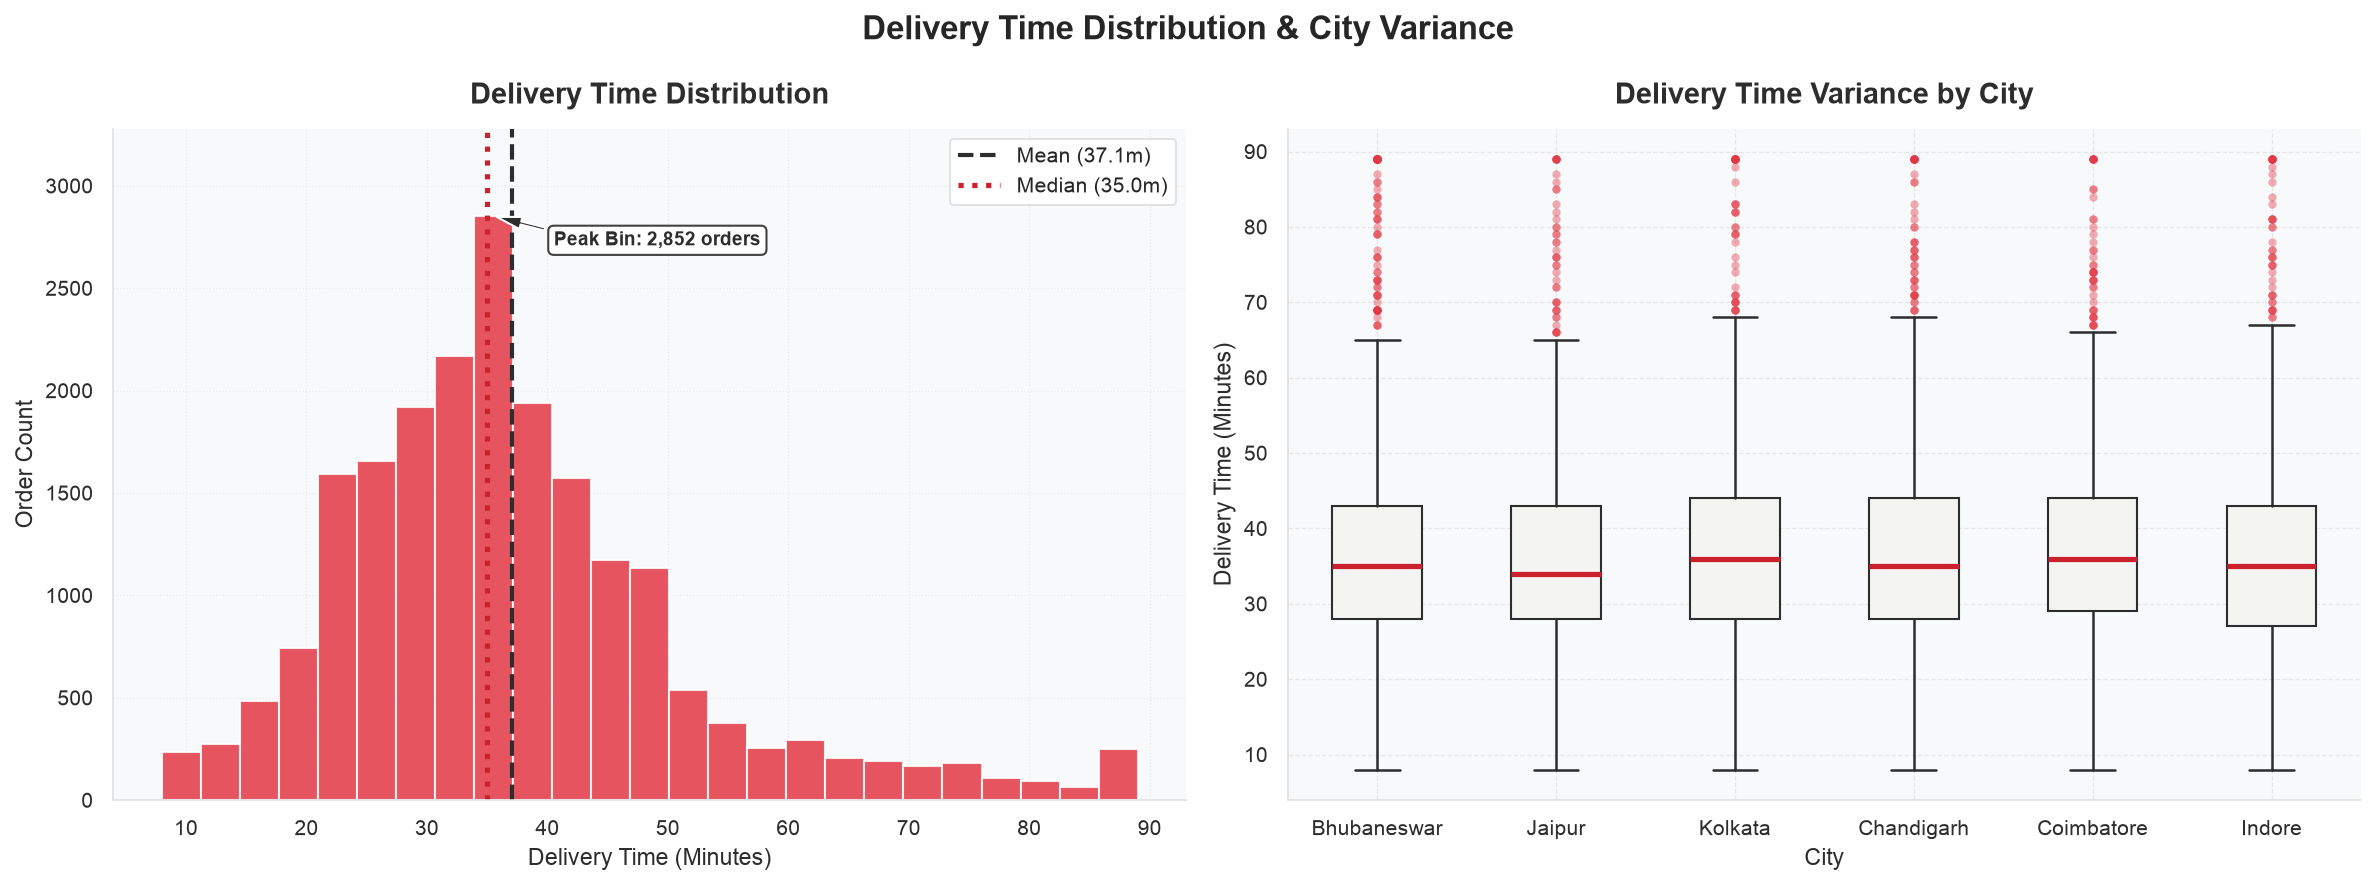

In [196]:
fig, axes = plt.subplots(1, 2, figsize = (16,6))
fig.suptitle(
    'Delivery Time Distribution & City Variance',

)
# Histogram : Delivery time distribution
n_counts, bin_edges, patches = axes[0].hist(
    orders_tw['DeliveryTimeCapped'],
    bins=25,
    color=ZOMATO_RED,
    edgecolor='white',
    alpha=0.85,
)
mean_dt = orders_tw['DeliveryTimeCapped'].mean()
median_dt = orders_tw['DeliveryTimeCapped'].median()
axes[0].axvline(
    mean_dt,
    color=CHARCOAL,
    linestyle='--',
    linewidth=2,
    label=f'Mean ({mean_dt:.1f}m)',
)
axes[0].axvline(
    median_dt,
    color=ZOMATO_DARK_RED,
    linestyle=':',
    linewidth=2.5,
    label=f'Median ({median_dt:.1f}m)',
)

# Annotate Peak Bin
max_bin_count = int(n_counts.max())
max_bin_idx = n_counts.argmax()
peak_bin_center = (
    bin_edges[max_bin_idx] + bin_edges[max_bin_idx + 1]
) / 2

axes[0].annotate(
    f'Peak Bin: {max_bin_count:,} orders',
    xy=(peak_bin_center, max_bin_count),
    xytext=(peak_bin_center + 5, max_bin_count * 0.95),
    arrowprops=dict(
        facecolor=CHARCOAL, shrink=0.05, width=1.5, headwidth=6
    ),
    fontweight='bold',
    color=CHARCOAL,
    fontsize=9,
    bbox=dict(
        boxstyle='round,pad=0.3', facecolor='white', edgecolor=CHARCOAL, alpha=0.9
    ),
)

axes[0].set_ylim(0, max_bin_count * 1.15)
axes[0].set_title(
    'Delivery Time Distribution',
    fontname = 'Arial',
    fontsize=14,
    fontweight='bold',
    color=CHARCOAL,
)
axes[0].set_xlabel('Delivery Time (Minutes)')
axes[0].set_ylabel('Order Count')
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend(loc='upper right', frameon=True)

# Delivery Time by Top cities
top_cities_list = orders_tw['City'].value_counts().head(6).index.tolist()
city_box_data = [
    orders_tw[orders_tw['City'] == c]['DeliveryTimeCapped'].dropna()
    for c in top_cities_list
]

bp = axes[1].boxplot(
    city_box_data,
    tick_labels=top_cities_list,
    patch_artist=True,
    medianprops={"color": ZOMATO_DARK_RED, "linewidth": 2.5},
    boxprops={"facecolor": NEUTRAL_BOX, "edgecolor": CHARCOAL},
    whiskerprops={"color": CHARCOAL, "linewidth": 1.2},
    capprops={"color": CHARCOAL, "linewidth": 1.2},
    flierprops={
        "marker": "o",
        "markerfacecolor": ZOMATO_RED,
        "markeredgecolor": "none",
        "alpha": 0.4,
        "markersize": 4,
    },
)

axes[1].set_title("Delivery Time Variance by City")
axes[1].set_xlabel("City")
axes[1].set_ylabel("Delivery Time (Minutes)")

plt.show()


Output:
- The mean time delivery 37.1min is higher than median time delivery 35min, suggesting a right-skewed distribution caused by long-tail delayed orders pulling the average up.
- There is a slight upward bump in the 85-90min window suggesting the capped values of delayed orders or some systematic issues.
- In the right plot, every city shows a dense trail of severe upper outliers extending beyond 65 minutes up to 90 minutes.
- The minimum 8min and maximum 65min is a consistent trend in all the top cities suggesting that delays are not city-specific, rather very consistent showing structural delay pattern.

### Basket Size & Membership ###

In [209]:
# 1. Join Orders with Customers to pull Membership

orders_cm = orders.copy()
if 'Membership' not in orders_cm.columns and 'CustomerID' in orders_cm.columns:
    orders_cm = orders_cm.merge(
        customers[['CustomerID', 'Membership']], on='CustomerID', how='left'
    )


In [210]:

# Fallback default if Membership is unassigned
orders_cm['Membership'] = orders_cm['Membership'].fillna('Standard')

# 2. Join Order Items to aggregate Item Count per Order (Basket Size)
if 'OrderID' in order_items.columns:
    basket_counts = (
        order_items.groupby('OrderID')
        .size()
        .reset_index(name='ItemsPerOrder')
    )
    orders_cm = orders_cm.merge(basket_counts, on='OrderID', how='left')
    orders_cm['ItemsPerOrder'] = orders_cm['ItemsPerOrder'].fillna(1).astype(int)

# 3. Extract Tier Order by Frequency (Basic, Gold, Zomato Pro, Standard)
tier_order = (
    orders_cm['Membership'].value_counts().index.tolist()
)

In [211]:

# Summary Stats by Membership Tier
tier_summary = (
    orders_cm.groupby('Membership')
    .agg(
        AverageOrderValue=('FinalAmount', 'mean'),
        MedianOrderValue=('FinalAmount', 'median'),
        AvgItemsPerOrder=('ItemsPerOrder', 'mean'),
        TotalOrders=('OrderID', 'count')
    )
    .reset_index()
)

print("Membership tier basket economics:")
print(tier_summary.to_string(index=False))

Membership tier basket economics:
Membership  AverageOrderValue  MedianOrderValue  AvgItemsPerOrder  TotalOrders
     Basic         392.265334            383.25          2.071908        12071
      Gold         391.427081            382.60          2.057172         3953
  Standard         396.646154            388.00          2.046154          195
Zomato Pro         390.199248            381.75          2.072368         4256


#### Visualization of Membership Tier-wise basket size ####

/var/folders/14/vwm12jsj6k54dqpcrph9h29w0000gp/T/ipykernel_37856/2506384277.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


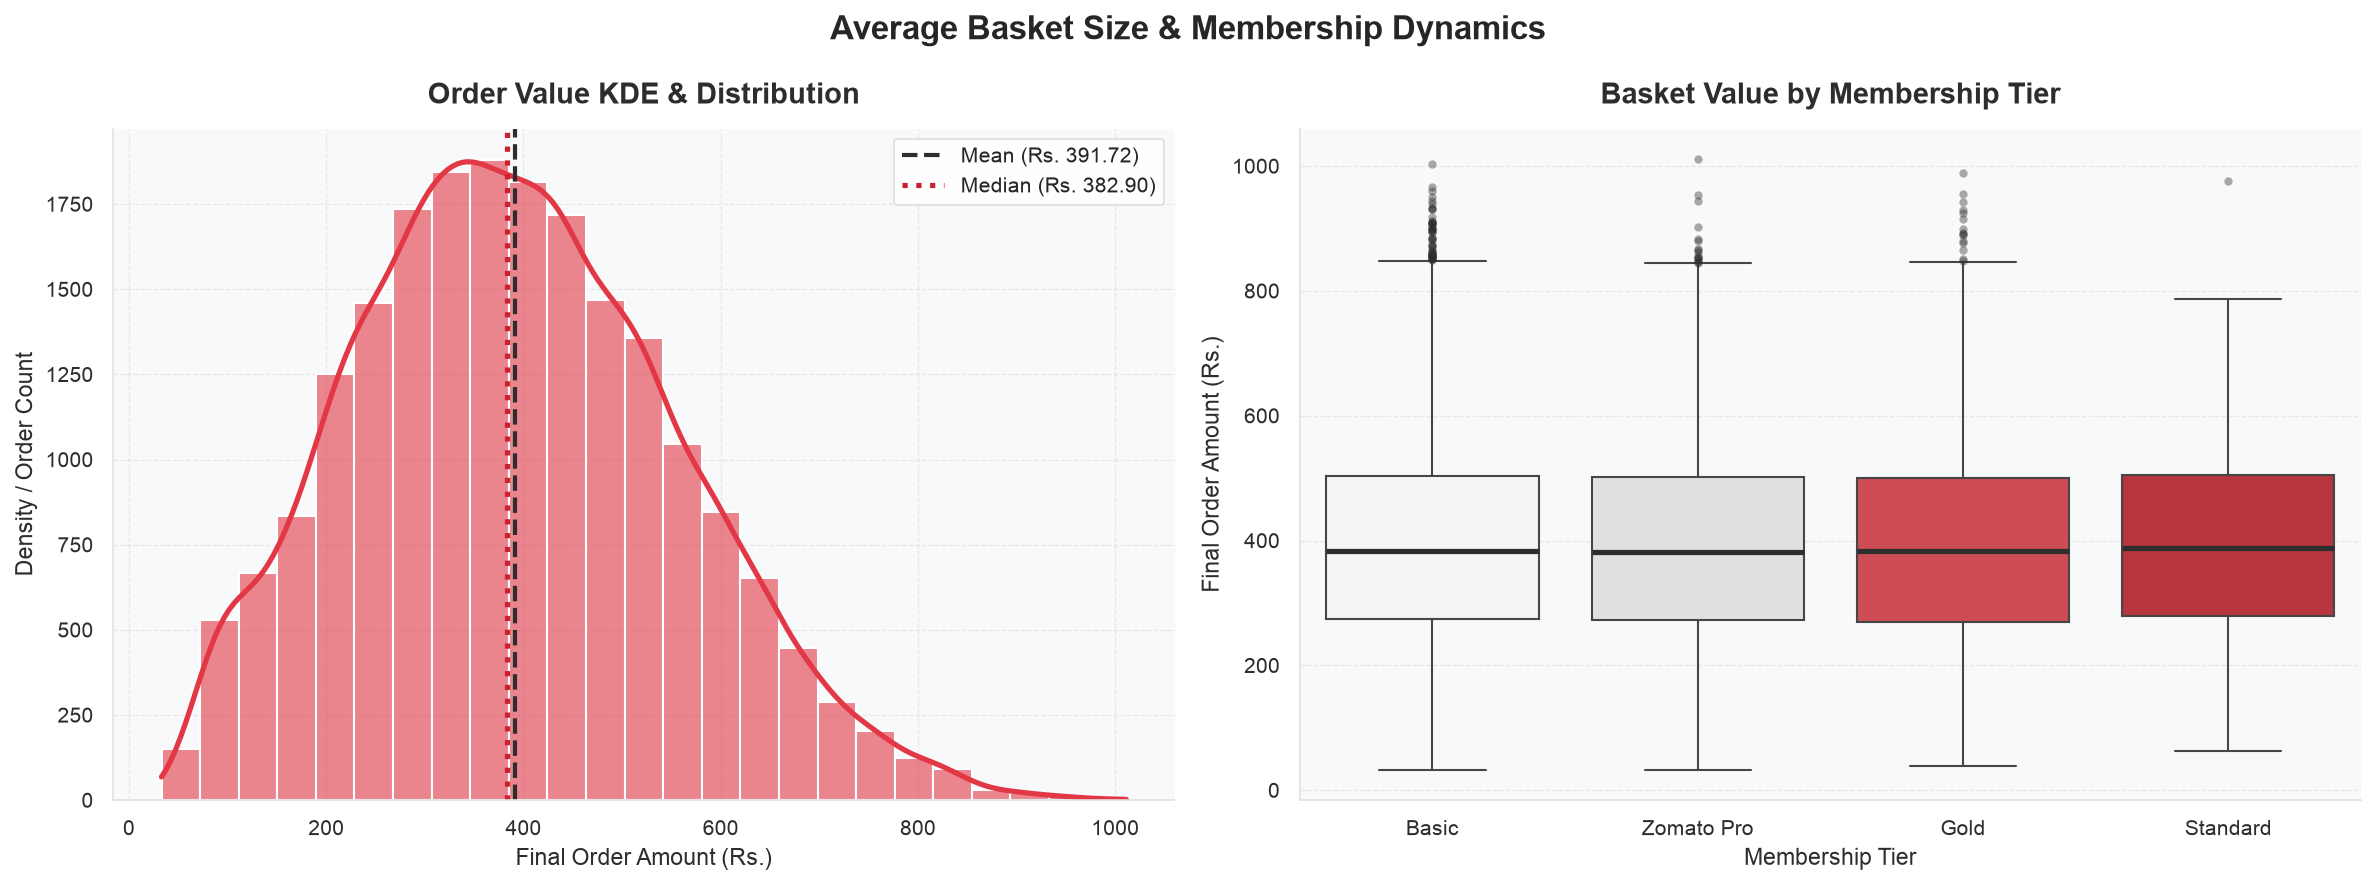

In [215]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Average Basket Size & Membership Dynamics")

sns.histplot(
    data=orders_cm,
    x='FinalAmount',
    kde=True,
    bins=25,
    color=ZOMATO_RED,
    line_kws={'linewidth': 2.5, 'color': ZOMATO_DARK_RED},
    alpha=0.6,
    ax=axes[0],
)

mean_aov = orders_cm['FinalAmount'].mean()
median_aov = orders_cm['FinalAmount'].median()

axes[0].axvline(
    mean_aov,
    color=CHARCOAL,
    linestyle='--',
    linewidth=2,
    label=f'Mean (Rs. {mean_aov:,.2f})',
)
axes[0].axvline(
    median_aov,
    color=ZOMATO_DARK_RED,
    linestyle=':',
    linewidth=2.5,
    label=f'Median (Rs. {median_aov:,.2f})',
)

axes[0].set_title(
    'Order Value KDE & Distribution',
    fontweight='bold',
    color=CHARCOAL,
)
axes[0].set_xlabel('Final Order Amount (Rs.)')
axes[0].set_ylabel('Density / Order Count')
axes[0].legend(loc='upper right')

# Basket Value by Membership Tier
sns.boxplot(
    data=orders_cm,
    x='Membership',
    y='FinalAmount',
    order=tier_order,
    palette=[NEUTRAL_BOX, NEUTRAL_GREY, ZOMATO_RED, ZOMATO_DARK_RED],
    medianprops={'color': CHARCOAL, 'linewidth': 2.5},
    flierprops={
        'marker': 'o',
        'markerfacecolor': CHARCOAL,
        'markeredgecolor': 'none',
        'alpha': 0.4,
        'markersize': 4,
    },
    ax=axes[1],
)

axes[1].set_title(
    'Basket Value by Membership Tier',
    fontweight='bold',
    color=CHARCOAL,
)
axes[1].set_xlabel('Membership Tier')
axes[1].set_ylabel('Final Order Amount (Rs.)')

plt.tight_layout()
plt.show()

Output:
- In first plot, nearly symmetric bell-curve distribution centered between Rs. 300 and Rs. 500, tapering off smoothly toward Rs. 1,000. Highest order concentration occurs around the Rs. 300–400 basket size range (peaking near 1,850 orders).
- In the box plot, IQR of all tiers are identical ranging 270-500 rup. 
- Upper outliers extend up to Rs. 1,000 across Basic, Zomato Pro, and Gold tiers, while Standard has slightly fewer high-end outliers beyond Rs. 800.
- It is observed that membership tier does not influence basket size but subscription benefits are driving the ordering frequency rather than basket size.

### Repeating vs One-Time Customers ###

In [231]:

orders_fc = orders.copy()
# 1. Calculate Total Unique Customers & Total Orders
total_unique_customers = orders_fc['CustomerID'].nunique()
total_orders_count = len(orders_fc)
# 2. Group by CustomerID and count orders
customer_freq = orders_fc.groupby('CustomerID').size().reset_index()

# 3. Explicitly rename columns to avoid key errors
customer_freq.columns = ['CustomerID', 'TotalOrders']

In [232]:
# 4. Explicit Segment Assignment (>= 2 is Repeat, == 1 is One-Time)
customer_freq['CustomerSegment'] = np.where(
    customer_freq['TotalOrders'] >= 2, 'Repeat', 'One-Time')

In [233]:
# 5. Value Counts Summary
segment_summary = (
    customer_freq['CustomerSegment']
    .value_counts()
    .reset_index()
)
segment_summary.columns = ['CustomerSegment', 'UserCount']

In [234]:
# Calculate Exact Percentage
segment_summary['Percentage'] = (
    segment_summary['UserCount'] / total_unique_customers
) * 100

# Extract Segment Metrics
repeat_users = segment_summary.loc[
    segment_summary['CustomerSegment'] == 'Repeat', 'UserCount'
].values[0]

onetime_users = segment_summary.loc[
    segment_summary['CustomerSegment'] == 'One-Time', 'UserCount'
].values[0]

repeat_rate_pct = (repeat_users / total_unique_customers) * 100
avg_purchase_freq = total_orders_count / total_unique_customers

In [236]:
print("Customer retention metrics summary")
print(f"Total Unique Customers : {total_unique_customers:,}")
print(f"One-Time Customers     : {onetime_users:,} ({(onetime_users/total_unique_customers)*100:.2f}%)")
print(f"Repeat Customers (2+)  : {repeat_users:,} ({repeat_rate_pct:.2f}%)")
print(f"Avg Purchase Frequency : {avg_purchase_freq:.2f} orders/customer")
print("\nSegment Summary Matrix:")
print(segment_summary.to_string(index=False))

Customer retention metrics summary
Total Unique Customers : 9,827
One-Time Customers     : 3,715 (37.80%)
Repeat Customers (2+)  : 6,112 (62.20%)
Avg Purchase Frequency : 2.08 orders/customer

Segment Summary Matrix:
CustomerSegment  UserCount  Percentage
         Repeat       6112   62.195991
       One-Time       3715   37.804009


#### Visualization of Customer Retention Summary ####

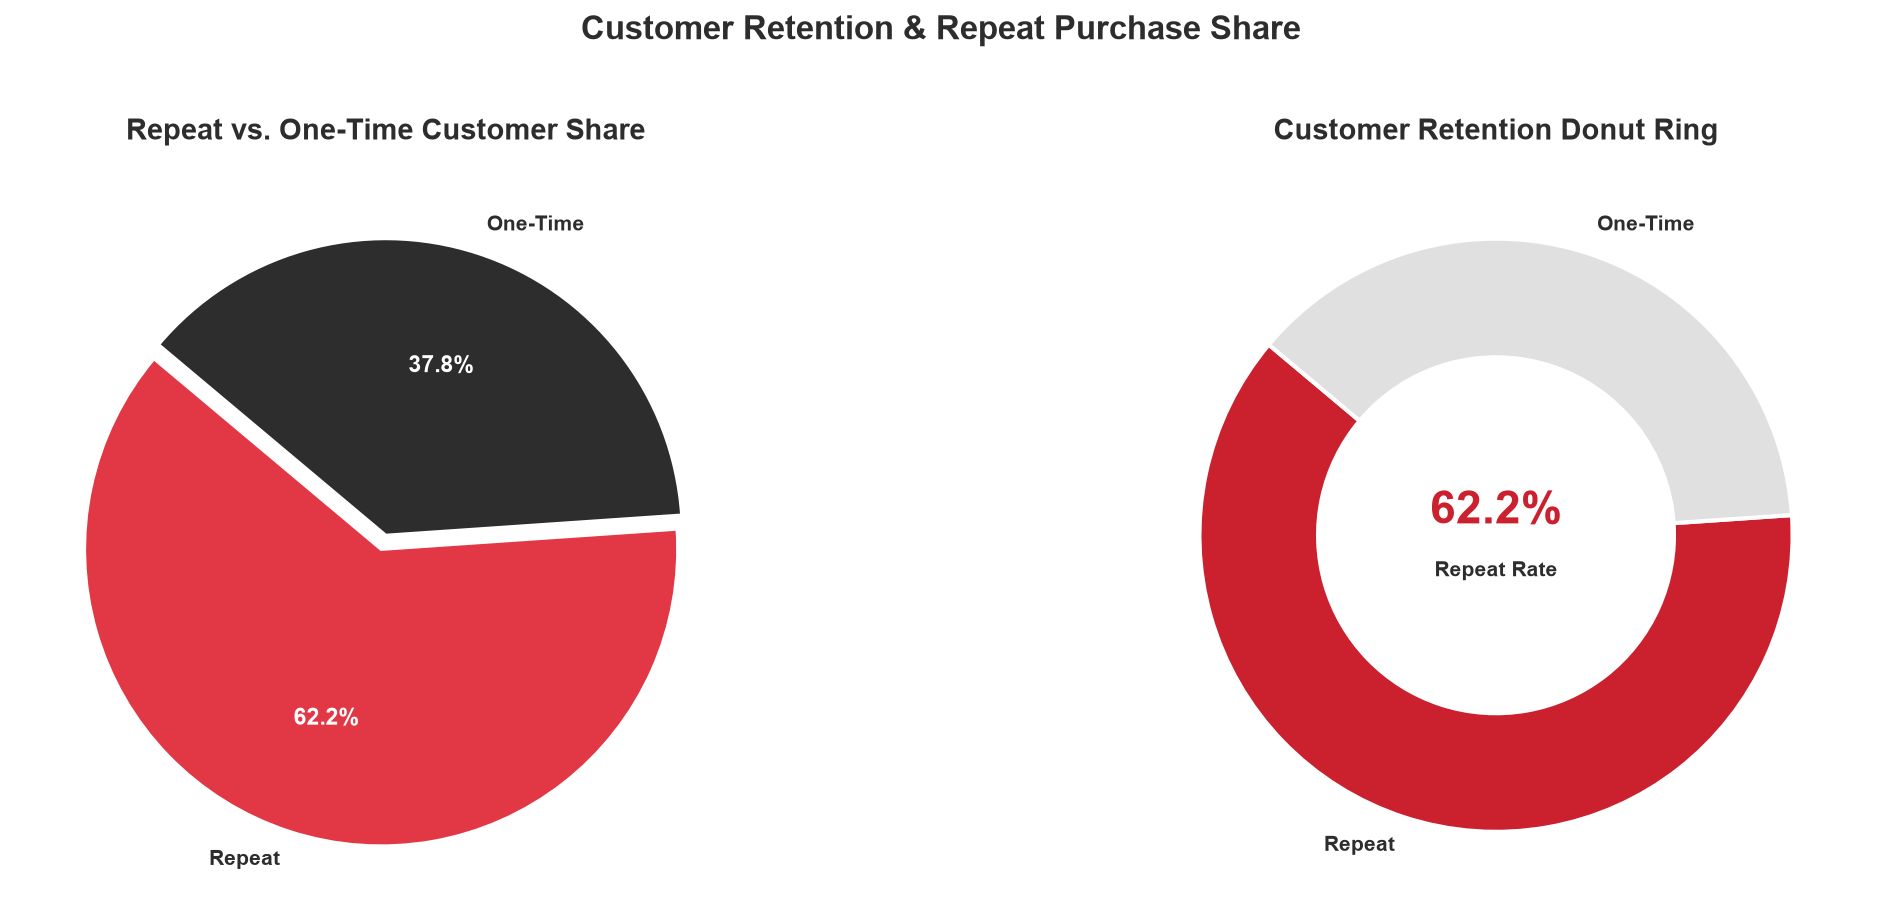

In [239]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    "Customer Retention & Repeat Purchase Share",
    fontsize=16,
    fontweight="bold",
    color=CHARCOAL,
    y=1.02,
)

labels = segment_summary['CustomerSegment'].tolist()
counts = segment_summary['UserCount'].tolist()
colors = [ZOMATO_RED, CHARCOAL]
explode = (0.05, 0)

# Standard Proportional Share
wedges, texts, autotexts = axes[0].pie(
    counts,
    labels=labels,
    autopct="%1.1f%%",
    startangle=140,
    colors=colors,
    explode=explode,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)

for text in texts:
  text.set_color(CHARCOAL)
  text.set_fontweight("bold")

for autotext in autotexts:
  autotext.set_color("white")
  autotext.set_fontweight("bold")
  autotext.set_fontsize(11)

axes[0].set_title("Repeat vs. One-Time Customer Share")

# Customer Retention Ring
wedges_d, texts_d = axes[1].pie(
    counts,
    labels=labels,
    autopct=None,
    startangle=140,
    colors=[ZOMATO_DARK_RED, NEUTRAL_GREY],
    pctdistance=0.75,
    wedgeprops={"width": 0.4, "edgecolor": "white", "linewidth": 2},
)

# Central Circle
centre_circle = plt.Circle((0, 0), 0.55, fc="white")
axes[1].add_artist(centre_circle)

# Exact Dynamic Repeat Rate Callout
axes[1].text(
    0,
    0.08,
    f"{repeat_rate_pct:.1f}%",
    ha="center",
    va="center",
    fontsize=22,
    fontweight="bold",
    color=ZOMATO_DARK_RED,
)
axes[1].text(
    0,
    -0.12,
    "Repeat Rate",
    ha="center",
    va="center",
    fontsize=10,
    fontweight="bold",
    color=CHARCOAL,
)

for text in texts_d:
  text.set_color(CHARCOAL)
  text.set_fontweight("bold")

axes[1].set_title("Customer Retention Donut Ring")

plt.tight_layout()
plt.show()

Output:
- This suggests 62.20% of your active customer base (6,112 users) are repeat customers who have placed 2 or more orders.
- 37.80% of customers (3,715 users) placed only a single order.
- Across all 9,827 unique customers, the network averages 2.08 orders per customer.